# AIDI 1011 AI Project - Heart Disease Classifier
### Team members:
#### Kam Hung Chan
#### Josiah Grimm
#### Jay Patel

# Introduction

# Problem Statement
#####Electrocardiogram (ECG) interpretation is a complex and time-consuming task that requires specialized clinical expertise. Due to a shortage of cardiology and cardiac physiology professionals in clinics, healthcare centers, and ambulance services, manually reviewing all ECG recordings for potential heart abnormalities can be challenging and prone to inconsistency. There is a growing need for an automated system that can assist clinicians and paramedics by identifying abnormal ECG patterns that may indicate heart disease, enabling faster, more consistent, and more reliable screening.

# Scope
#####The project focuses on developing an AI-based classification model using the PTB-XL dataset (Wagner et al., 2020), which contains over 20,000 clinically annotated 12-lead ECG recordings. The system is intended to serve as a decision-support tool, capable of:
* Analyzing 12-lead ECG signals to detect abnormal patterns
* Performing multiclass heart disease classification into clinically relevant categories
* Supporting pre-diagnosis or screening to prioritize ECGs for further medical review

# Exclusions / Boundaries:
* The model is not intended for real-time diagnosis or clinical use
* It will not provide treatment recommendations or replace clinician judgment
* Focus is on offline classification and educational research purposes




# Dataset Description (PTB-XL)
#####The PTB-XL dataset is a large, publicly available clinical ECG dataset collected in Germany at the Physikalisch-Technische Bundesanstalt (PTB) and the University Medical Center Mainz, and later published on PhysioNet. It contains 21,837 ten-second 12-lead ECG recordings sampled at 100 Hz and 500 Hz, with expert annotations provided as SCP codes that map to diagnostic superclasses such as MI, STTC, CD, HYP, and NORM. In addition to the ECG signals, the dataset includes patient metadata such as age and sex, making it a widely used benchmark for developing and evaluating AI models for automated ECG classification (Wagner et al., 2020).

# Literature Review


#### Kam's literature Review
Śmigiel et al. (2021) investigated deep learning approaches for automatic ECG classification using the PTB-XL dataset, focusing on designing lightweight yet effective models for multi-class diagnosis. After filtering the dataset to 17,232 high-confidence labeled ECG records sampled at 100 Hz, the authors evaluated three architectures for 2-class, 5-class, and 20-class classification: a compact 1D convolutional neural network (CNN), a SincNet-based model originally designed for speech signals, and a CNN augmented with entropy-based signal features. The study emphasized computational efficiency, using small models suitable for embedded or mobile deployment, and assessed performance using accuracy, precision, recall, F1-score, and AUC.

The key finding of the study was that combining CNN features with entropy measures (e.g., Shannon, sample, permutation, spectral entropy) significantly improved classification performance across all tasks. The CNN with entropy features achieved the best results, reaching 76.5% accuracy for five diagnostic classes and 69.8% for twenty subclasses, outperforming both the basic CNN and the much larger SincNet model. The authors concluded that while simple 1D CNNs are highly effective for ECG signals, incorporating handcrafted signal complexity features can further enhance performance in multi-class ECG diagnosis using PTB-XL.

# Jay please eleect a paper and do your literature review here
//
//
//


# Josiah please eleect a paper and do your literature review here
// // //


# Exploratory Data Analysis

In [50]:
# install to setup the env if your colab notebook restarted
!pip install -U "pandas<2.2" wfdb

  Using cached wfdb-4.3.1-py3-none-any.whl.metadata (3.8 kB)
INFO: pip is looking at multiple versions of wfdb to determine which version is compatible with other requirements. This could take a while.
  Using cached wfdb-4.3.0-py3-none-any.whl.metadata (3.8 kB)
  Using cached wfdb-4.2.0-py3-none-any.whl.metadata (3.7 kB)


In [51]:
from google.colab import drive
import pandas as pd
import ast
import numpy as np
import wfdb
import matplotlib.pyplot as plt

drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [52]:
path = "/content/drive/MyDrive/ECGDataset/"


record_path = (
    path +
    "records100/00000/"
)

# for a single record
record = "00001_lr"

signal, meta = wfdb.rdsamp(record_path+record)

print(signal.shape)

(1000, 12)


In [53]:
signal

array([[-0.119, -0.055,  0.064, ..., -0.026, -0.039, -0.079],
       [-0.116, -0.051,  0.065, ..., -0.031, -0.034, -0.074],
       [-0.12 , -0.044,  0.076, ..., -0.028, -0.029, -0.069],
       ...,
       [ 0.069,  0.   , -0.069, ...,  0.024, -0.041, -0.058],
       [ 0.086,  0.004, -0.081, ...,  0.242, -0.046, -0.098],
       [ 0.022, -0.031, -0.054, ...,  0.143, -0.035, -0.12 ]])

In [54]:
# we use the 100hz waveform files
meta['fs']

100

In [55]:
# 12-lead ECG
meta['sig_name']

['I', 'II', 'III', 'AVR', 'AVL', 'AVF', 'V1', 'V2', 'V3', 'V4', 'V5', 'V6']

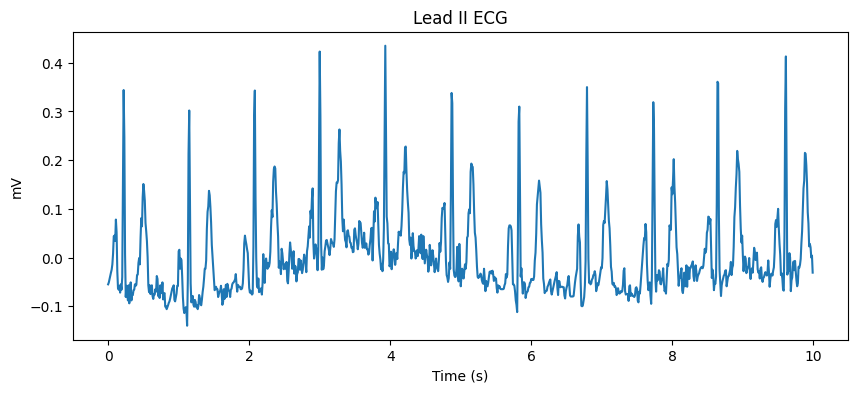

In [56]:
fs = meta['fs']
time = np.arange(signal.shape[0]) / fs

plt.figure(figsize=(10,4))
plt.plot(time, signal[:, 1])  # Lead II
plt.xlabel("Time (s)")
plt.ylabel("mV")
plt.title("Lead II ECG")
plt.show()

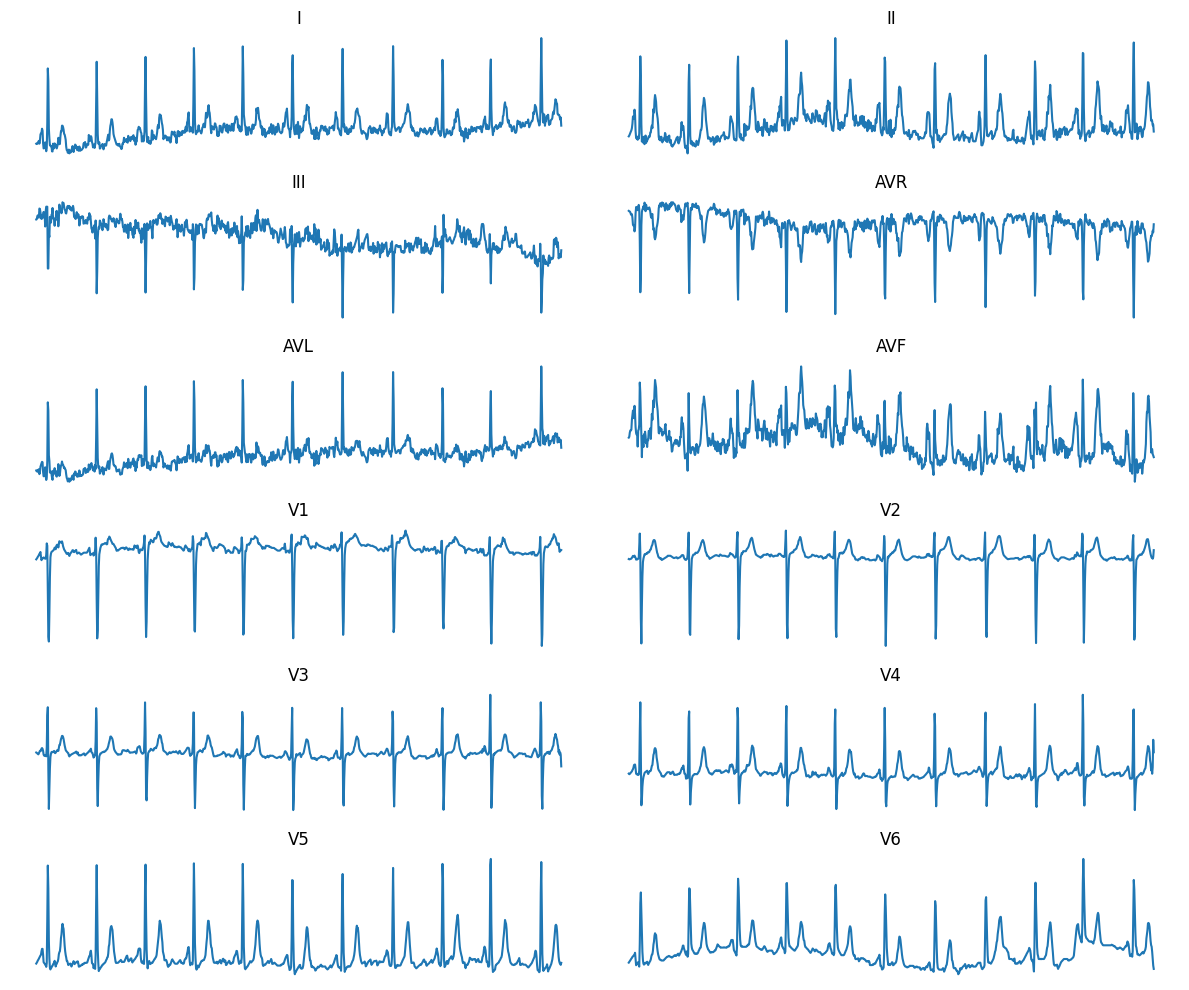

In [57]:
plt.figure(figsize=(12,10))
for i in range(12):
    plt.subplot(6, 2, i+1)
    plt.plot(time, signal[:, i])
    plt.title(meta['sig_name'][i])
    plt.axis('off')
plt.tight_layout()
plt.show()

In [58]:
# load and convert annotation data
Y = pd.read_csv("/content/drive/MyDrive/ECGDataset/"
            "ptbxl_database.csv", index_col='ecg_id')
Y.scp_codes = Y.scp_codes.apply(lambda x: ast.literal_eval(x))

In [59]:
# Google colab is too slow to load the data from drive
# loaded on PC and prepared the npy file instead
'''
# create a function to load data
def load_raw_data(df, sampling_rate, path):
    if sampling_rate == 100:
        data = [wfdb.rdsamp(path+f) for f in df.filename_lr]
    else:
        data = [wfdb.rdsamp(path+f) for f in df.filename_hr]
    data = np.array([signal for signal, meta in data])
    return data

sampling_rate=100

# Load raw signal data
X = load_raw_data(Y, sampling_rate, path)
'''

'\n# create a function to load data\ndef load_raw_data(df, sampling_rate, path):\n    if sampling_rate == 100:\n        data = [wfdb.rdsamp(path+f) for f in df.filename_lr]\n    else:\n        data = [wfdb.rdsamp(path+f) for f in df.filename_hr]\n    data = np.array([signal for signal, meta in data])\n    return data\n\nsampling_rate=100\n\n# Load raw signal data\nX = load_raw_data(Y, sampling_rate, path)\n'

In [60]:
# save as npy file to be read much quickly
# np.save(path + "X_ptbxl_100hz.npy", X)

In [61]:
X = np.load(path + "X_ptbxl_100hz.npy", mmap_mode='r')

In [62]:
# Load scp_statements.csv for diagnostic aggregation
agg_df = pd.read_csv(path+'scp_statements.csv', index_col=0)
agg_df = agg_df[agg_df.diagnostic == 1]

In [65]:
def aggregate_diagnostic(y_dic):
    tmp = []
    for key in y_dic.keys():
        if key in agg_df.index:
            tmp.append(agg_df.loc[key].diagnostic_class)
    return list(set(tmp))

# Apply diagnostic superclass
Y['diagnostic_superclass'] = Y.scp_codes.apply(aggregate_diagnostic)


diagnostic_superclass
NORM    9514
MI      5469
STTC    5235
CD      4898
HYP     2649
Name: count, dtype: int64


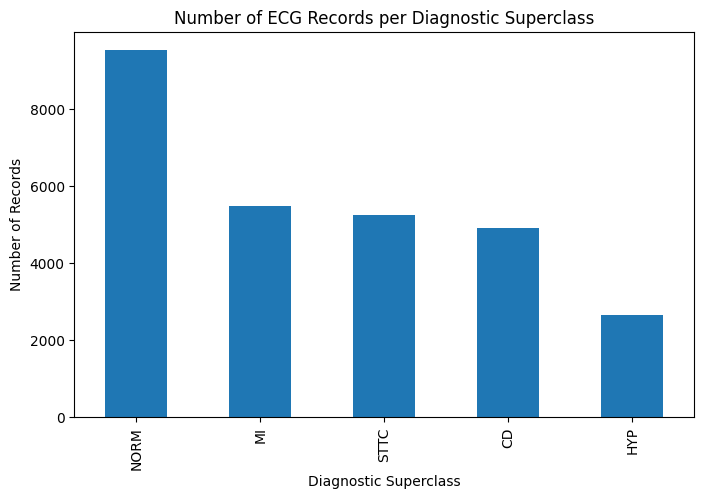

In [66]:
# explode the list of classes into rows
exploded = Y.explode('diagnostic_superclass')

# count occurrences
class_counts = exploded['diagnostic_superclass'].value_counts()

print(class_counts)

plt.figure(figsize=(8,5))
class_counts.plot(kind='bar')
plt.title('Number of ECG Records per Diagnostic Superclass')
plt.xlabel('Diagnostic Superclass')
plt.ylabel('Number of Records')
plt.show()

In [67]:
# number of labels per ECG
Y['num_labels'] = Y['diagnostic_superclass'].apply(len)

label_count_distribution = Y['num_labels'].value_counts().sort_index()

print(label_count_distribution)

num_labels
0      411
1    16244
2     4068
3      919
4      157
Name: count, dtype: int64


In [68]:
# check if 'NORM' is in the label list
Y['has_norm'] = Y['diagnostic_superclass'].apply(lambda x: 'NORM' in x)

norm_records = Y[Y['has_norm']]

In [69]:
# pure NORM = only 1 label and that label is NORM
pure_norm = norm_records[
    norm_records['diagnostic_superclass'].apply(lambda x: len(x) == 1)
]

# NORM + other classes
norm_with_others = norm_records[
    norm_records['diagnostic_superclass'].apply(lambda x: len(x) > 1)
]

print("Pure NORM records:", len(pure_norm))
print("NORM with other classes:", len(norm_with_others))

Pure NORM records: 9069
NORM with other classes: 445


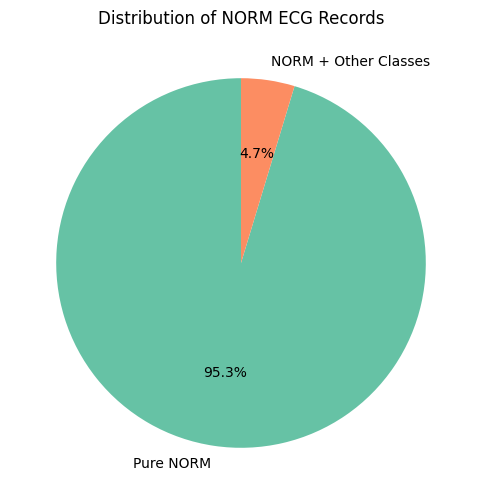

In [70]:
# Count the two categories
pure_count = len(pure_norm)
mixed_count = len(norm_with_others)

# Labels and sizes for pie chart
labels = ['Pure NORM', 'NORM + Other Classes']
sizes = [pure_count, mixed_count]

# Plot pie chart
plt.figure(figsize=(6,6))
plt.pie(
    sizes,
    labels=labels,
    autopct='%1.1f%%',  # Show percentage
    startangle=90,
    colors=['#66c2a5','#fc8d62']  # optional nice colors
)
plt.title('Distribution of NORM ECG Records')
plt.show()

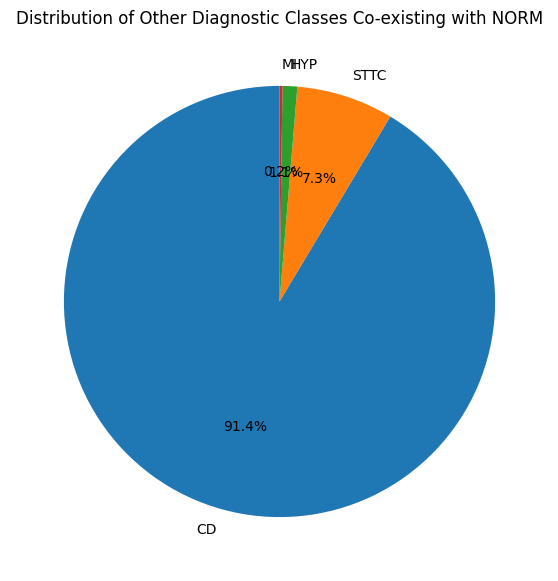

In [71]:
from collections import Counter

other_labels = []

for labels_list in norm_with_others['diagnostic_superclass']:
    for label in labels_list:
        if label != 'NORM':
            other_labels.append(label)

counter = Counter(other_labels)

total_mixed = len(norm_with_others)

labels = list(counter.keys())
counts = list(counter.values())
percentages = [(c / total_mixed) * 100 for c in counts]

plt.figure(figsize=(7,7))
plt.pie(percentages, labels=labels, autopct='%1.1f%%', startangle=90)
plt.title('Distribution of Other Diagnostic Classes Co-existing with NORM')
plt.show()

# Data Cleaning

In [97]:
Y_superclass = Y[Y['diagnostic_superclass'].apply(lambda x: len(x) > 0)]
print('Total Record', len(Y))
print('Records classified into superclasses: ', len(Y_superclass))
print('Records without superclasses: ', len(Y) - len(Y_superclass))

Total Record 21799
Records classified into superclasses:  21388
Records without superclasses:  411


In [84]:
diagnostic_codes = agg_df[agg_df['diagnostic_class'].notna()].index

def has_low_conf_diag(scp_dict):
    for code, conf in scp_dict.items():
        if code in diagnostic_codes and conf < 100:
            return True
    return False

low_conf_records = Y[Y['scp_codes'].apply(has_low_conf_diag)]
print(len(low_conf_records))

7021


In [89]:
# Remove records with low confidence (7021 records)
def is_full_confidence_diag(scp_dict):
    for code, conf in scp_dict.items():
        if code in diagnostic_codes and conf < 100:
            return False
    return True

Y_clean = Y[Y['scp_codes'].apply(is_full_confidence_diag)]

In [93]:
# Remove records without superclasses (411 records)
Y_clean = Y_clean[Y_clean['diagnostic_superclass'].apply(lambda x: len(x) > 0)]

In [92]:
print("Original:", len(Y))
print("After 100% confidence filter:", len(Y_clean))

Original: 21799
After 100% confidence filter: 14367


In [ ]:
# draft
'''

# Split data into train and test
test_fold = 10
# Train
X_train = X[np.where(Y.strat_fold != test_fold)]
y_train = Y[(Y.strat_fold != test_fold)].diagnostic_superclass
# Test
X_test = X[np.where(Y.strat_fold == test_fold)]
y_test = Y[Y.strat_fold == test_fold].diagnostic_superclass

'''

# References

Śmigiel, S., Pałczyński, K., & Ledziński, D. (2021). ECG signal classification using deep learning techniques based on the PTB-XL dataset. Entropy, 23(9), 1121. https://doi.org/10.3390/e23091121

Wagner, P., Strodthoff, N., Bousseljot, R., Samek, W., & Schaeffter, T. (2020). PTB-XL, a large publicly available electrocardiography dataset. Scientific Data, 7, 154. https://doi.org/10.1038/s41597-020-0495-6